In [1]:
# Voice of Customer Analysis — THEHOTEL.com
#
# Business objective:
#   Management cannot act on 47 000 individual reviews.
#   This analysis surfaces the top 3 operational areas driving guest
#   dissatisfaction so the operations team can prioritise remediation,
#   and tests whether dissatisfaction patterns differ by guest segment
#   and shift over the two-month review window.
#
# Notebook structure:
#   Part 1 : Setup
#   Part 2 : Data loading and raw inspection
#   Part 3 : Cleaning
#   Part 4 : EDA and key statistics
#   Part 5 : Sentiment analysis  (XLM-RoBERTa primary, VADER secondary)
#   Part 6 : Negative review theme extraction  (BERTopic)
#   Part 7 : Business recommendations
#
# Data:
#   Upload reviews.csv to Colab via the Files panel before running.
#   Expected path: /content/reviews.csv

In [2]:
# Part 1: Setup

# install non-standard dependencies (run once per Colab session)
!pip install -q transformers torch bertopic sentence-transformers vaderSentiment datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 15.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_PATH = Path('/content/reviews.csv')

plt.rcParams.update({
    'figure.figsize'   : (10, 4),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})
PALETTE = ['#2C5F8A', '#E07B39', '#4A9B6F', '#C94040', '#8A6BBE']

print('setup complete')

setup complete


In [4]:
# Part 2: Data Loading and Raw Inspection
#
# Inspect the raw file before writing any cleaning rules.

raw = pd.read_csv(
    DATA_PATH,
    encoding='utf-8',
    parse_dates=['Review created'],
)

print('--- shape and dtypes ---')
raw.info()

print('\n--- missing values per column ---')
print(raw.isna().sum().to_string())

print(f'\n--- date range ---')
print(f"  {raw['Review created'].min().date()}  to  {raw['Review created'].max().date()}")

print(f'\n--- unique hotel brands ---')
print(f"  {raw['Hotel_Brand'].nunique()}")

--- shape and dtypes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47741 entries, 0 to 47740
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Hotel_Code            47741 non-null  int64         
 1   Review created        47741 non-null  datetime64[ns]
 2   Hotel_Brand           47741 non-null  int64         
 3   Language              47741 non-null  object        
 4   Text                  47741 non-null  object        
 5   Type of trip          47741 non-null  object        
 6   Your gender identity  47274 non-null  object        
 7   Your age group        45199 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 2.9+ MB

--- missing values per column ---
Hotel_Code                 0
Review created             0
Hotel_Brand                0
Language                   0
Text                       0
Type of trip               0
Your gend

In [5]:
# --- raw categorical distributions ---
# examine exact values and frequencies before deciding how to normalise

for col in ['Type of trip', 'Your gender identity', 'Your age group']:
    print(raw[col].value_counts(dropna=False).to_string())
    print()

Type of trip
couple      18187
family      11762
business     9478
single       4328
friends      3986

Your gender identity
Male                    24337
Female                  21937
Prefer not to answer      946
NaN                       467
Non-binary                 54

Your age group
35-54    19696
55-64    11064
65+       9179
25-34     4467
NaN       2542
18-24      793



In [6]:
# --- normalisation maps and valid-value sets ---
#
# gender   : 'Prefer not to answer' is a non-response equivalent to NaN;
#             unified with 'not disclosed' so all non-responses share one label

GENDER_NORM = {'Prefer not to answer': 'not disclosed'}

VALID_TRIP   = {'business', 'couple', 'family', 'single', 'friends'}
VALID_GENDER = {'Male', 'Female', 'Non-binary', 'not disclosed'}
VALID_LANG   = {'en', 'fr'}

print('normalisation maps defined')
print(f'  gender    : {GENDER_NORM}')

normalisation maps defined
  gender    : {'Prefer not to answer': 'not disclosed'}


In [7]:
# Part 3: Cleaning

df = raw.copy()

# --- 3.1  rename columns for convenience ---
df = df.rename(columns={
    'Hotel_Code'          : 'hotel_code',
    'Hotel_Brand'         : 'brand',
    'Review created'      : 'date',
    'Language'            : 'language',
    'Text'                : 'text',
    'Type of trip'        : 'trip_type',
    'Your gender identity': 'gender',
    'Your age group'      : 'age_group',
})

# --- 3.2  strip whitespace from all string columns ---
str_cols = ['language', 'text', 'trip_type', 'gender', 'age_group']
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# --- 3.3  normalise synonymous categorical values ---
df['gender'] = df['gender'].replace(GENDER_NORM)

# --- 3.4  fill remaining NaN demographics with 'not disclosed' ---
# gender and age are self-reported; 'not disclosed' is retained as its own
# category in all downstream analyses rather than imputed
df['gender'] = df['gender'].fillna('not disclosed')
df['age_group'] = df['age_group'].fillna('not disclosed')

# --- 3.5  drop exact duplicates keyed on hotel_code + date + text ---
# hotel_code identifies a specific property; brand identifies a chain.
# hotel_code is the stricter key: two properties of the same brand could
# legitimately receive identical text on the same date from different guests.
before = len(df)
df = df.drop_duplicates(subset=['hotel_code', 'date', 'text'])
dupes_removed = before - len(df)

# --- 3.6  derived features ---
df['text_length'] = df['text'].str.len()
df['week'] = df['date'].dt.to_period('W').dt.start_time

print('cleaning complete')
print(f'  duplicate rows removed : {dupes_removed}')
print(f'  rows after cleaning    : {len(df):,}')

cleaning complete
  duplicate rows removed : 0
  rows after cleaning    : 47,741


In [8]:
# --- 3.7  validate all categorical columns against expected value sets ---

checks = {
    'language' : VALID_LANG,
    'trip_type': VALID_TRIP,
    'gender'   : VALID_GENDER,
}

all_clean = True
for col, valid_set in checks.items():
    unexpected = set(df[col].unique()) - valid_set
    if unexpected:
        print(f'  {col}: unexpected values found -> {unexpected}')
        all_clean = False

if all_clean:
    print('all categorical columns validated — no unexpected values')

print()
print('final value distributions')
for col in ['language', 'trip_type', 'gender', 'age_group']:
    counts = df[col].value_counts(dropna=False)
    print(f'\n  {col}:')
    for val, cnt in counts.items():
        print(f'    {str(val):<25} {cnt:>8,}  ({cnt / len(df) * 100:.1f}%)')

all categorical columns validated — no unexpected values

final value distributions

  language:
    en                          28,787  (60.3%)
    fr                          18,954  (39.7%)

  trip_type:
    couple                      18,187  (38.1%)
    family                      11,762  (24.6%)
    business                     9,478  (19.9%)
    single                       4,328  (9.1%)
    friends                      3,986  (8.3%)

  gender:
    Male                        24,337  (51.0%)
    Female                      21,937  (46.0%)
    not disclosed                1,413  (3.0%)
    Non-binary                      54  (0.1%)

  age_group:
    35-54                       19,696  (41.3%)
    55-64                       11,064  (23.2%)
    65+                          9,179  (19.2%)
    25-34                        4,467  (9.4%)
    not disclosed                2,542  (5.3%)
    18-24                          793  (1.7%)


In [9]:
# --- cleaned dataset snapshot ---

print(f'cleaned dataframe — {len(df):,} rows')
df.head(3)

cleaned dataframe — 47,741 rows


,hotel_code,date,brand,language,text,trip_type,gender,age_group,text_length,week
0,0,2023-06-30,0,en,"Well appointed lobby and comfortable stay ,no ...",business,Male,35-54,64,2023-06-26
1,1,2023-06-30,1,en,Stayed because of meet the buyer.\nA bit quirk...,business,Female,65+,182,2023-06-26
2,2,2023-06-30,0,en,There was no service at the bar on the ground ...,business,Male,65+,116,2023-06-26


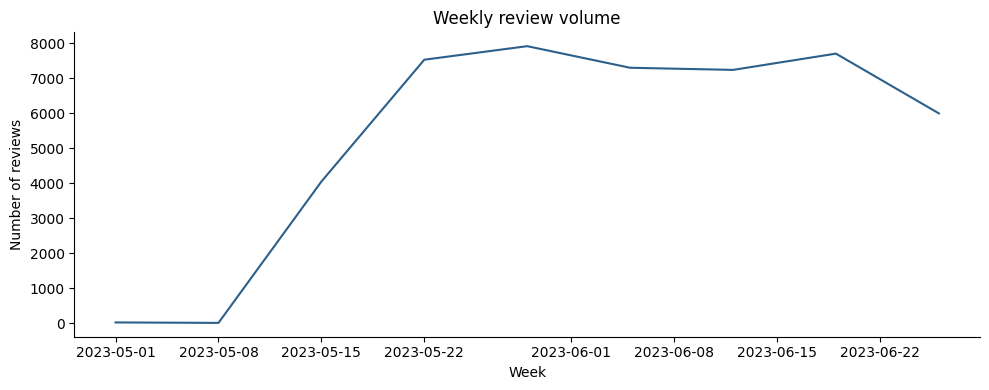

In [10]:
# Part 4: EDA and Key Statistics

# --- 4.1  review volume over time ---
# weekly aggregation smooths day-to-day noise

weekly = df.groupby('week').size()

fig, ax = plt.subplots()
ax.plot(weekly.index, weekly.values, color=PALETTE[0], linewidth=1.5)
ax.set_title('Weekly review volume')
ax.set_xlabel('Week')
ax.set_ylabel('Number of reviews')
plt.tight_layout()
plt.show()

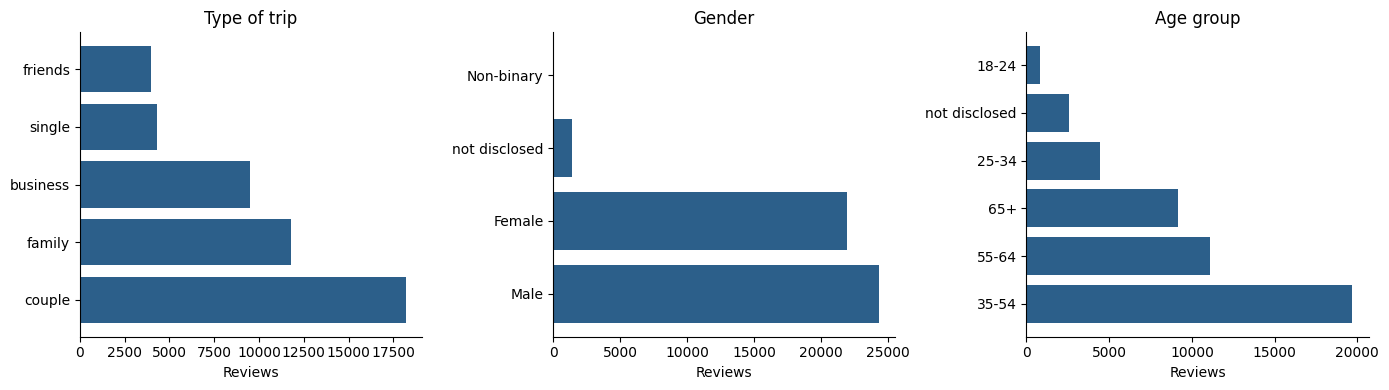

In [11]:
# --- 4.2  demographic distributions ---
# three panels: trip type, gender, age group

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['trip_type', 'gender', 'age_group'],
    ['Type of trip', 'Gender', 'Age group'],
):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color=PALETTE[0])
    ax.set_title(title)
    ax.set_xlabel('Reviews')

plt.tight_layout()
plt.show()

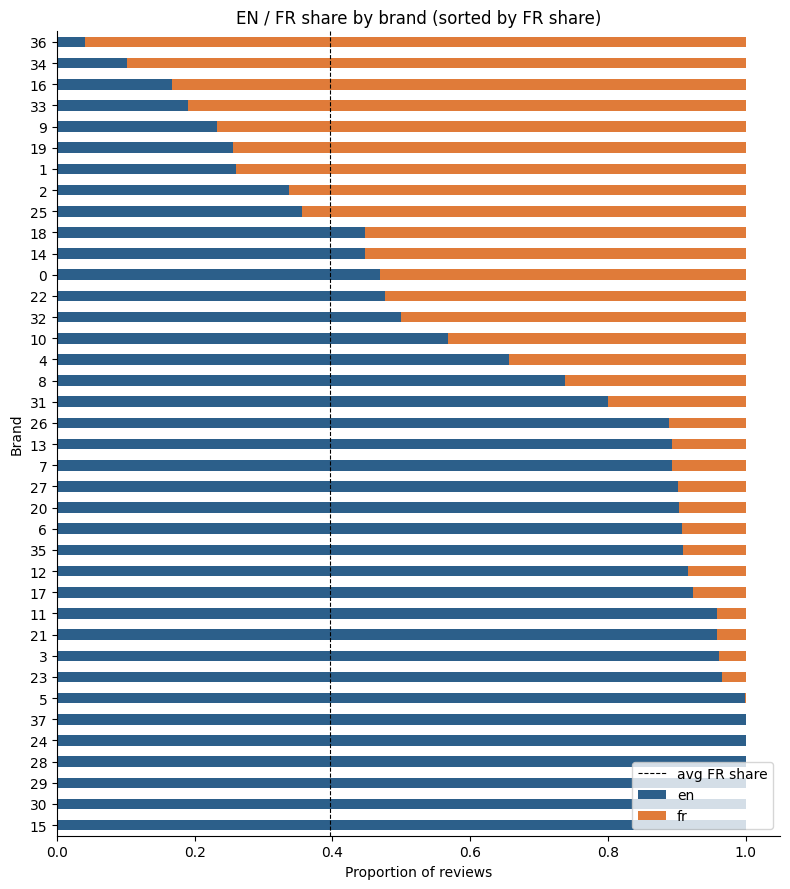

top 5 brands by FR share
brand
36    0.96
34    0.90
16    0.83
33    0.81
9     0.77


In [12]:
# --- 4.3  language split by brand ---
# Here we look at which brands are French-heavy
# French concentration may signal a specific audience
# or geographic cluster that warrants separate treatment in sentiment

lang_brand = pd.crosstab(df['brand'], df['language'], normalize='index')
lang_brand = lang_brand.sort_values('fr', ascending=True)  # ascending for barh readability

fig, ax = plt.subplots(figsize=(8, 9))
lang_brand.plot(
    kind='barh',
    stacked=True,
    color=[PALETTE[0], PALETTE[1]],
    ax=ax,
)
ax.axvline(df['language'].value_counts(normalize=True)['fr'], color='black',
           linestyle='--', linewidth=0.8, label='avg FR share')
ax.set_title('EN / FR share by brand (sorted by FR share)')
ax.set_xlabel('Proportion of reviews')
ax.set_ylabel('Brand')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# top 5 most French-heavy brands
print('top 5 brands by FR share')
print(lang_brand['fr'].sort_values(ascending=False).head().round(2).to_string())

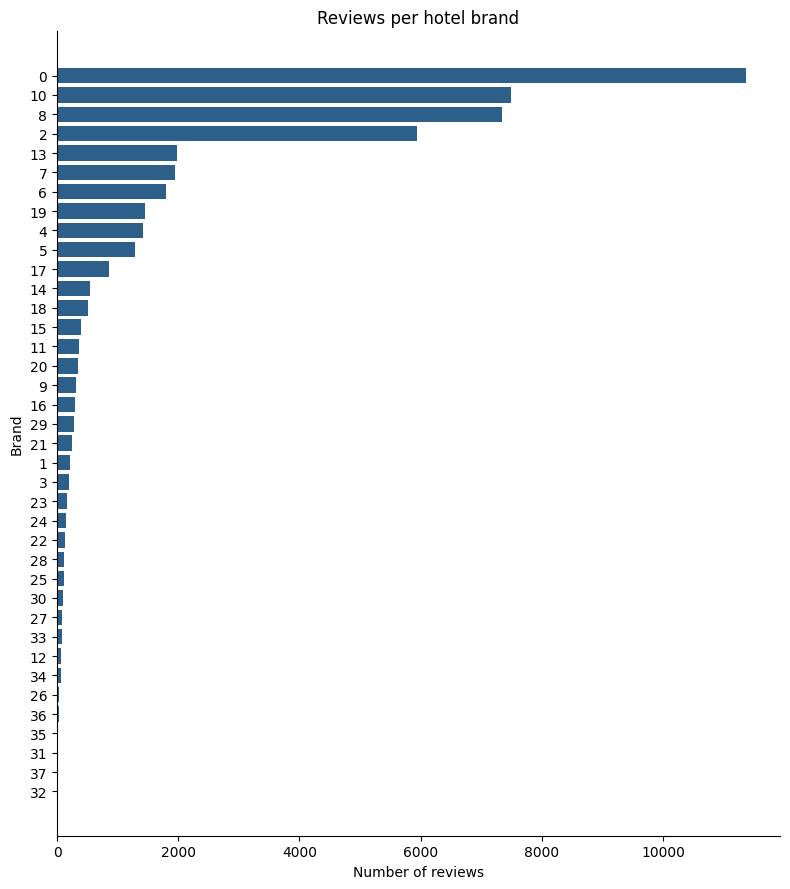

In [13]:
# --- 4.4  reviews per hotel brand ---
# shows which brands dominate the dataset

brand_counts = df['brand'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(brand_counts.index.astype(str), brand_counts.values, color=PALETTE[0])
ax.set_title('Reviews per hotel brand')
ax.set_xlabel('Number of reviews')
ax.set_ylabel('Brand')
plt.tight_layout()
plt.show()

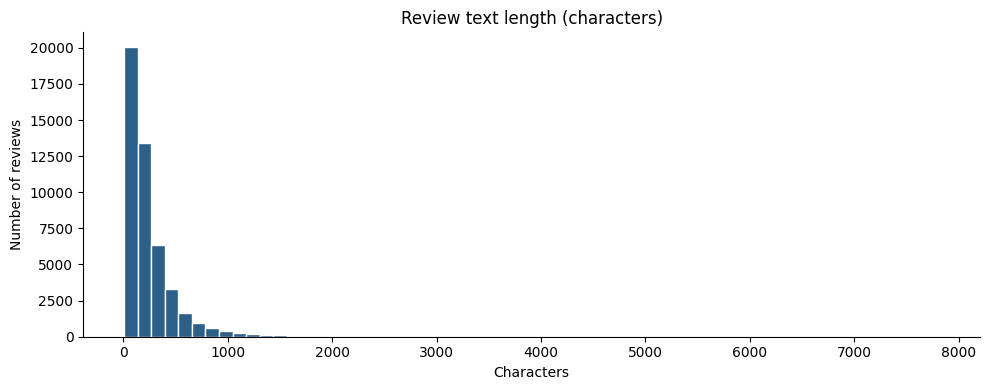

count    47741.0
mean       248.9
std        291.1
min          5.0
25%         87.0
50%        164.0
75%        304.0
max       7815.0


In [14]:
# --- 4.5  text length distribution ---
# longer reviews tend to carry more detail about specific complaints

fig, ax = plt.subplots()
ax.hist(df['text_length'], bins=60, color=PALETTE[0], edgecolor='white')
ax.set_title('Review text length (characters)')
ax.set_xlabel('Characters')
ax.set_ylabel('Number of reviews')
plt.tight_layout()
plt.show()

print(df['text_length'].describe().round(1).to_string())

(a) trip type share by brand
trip_type  business  couple  family  friends  single
brand                                               
0              0.20    0.39    0.19     0.09    0.13
1              0.40    0.30    0.10     0.09    0.10
2              0.17    0.42    0.22     0.08    0.11
3              0.35    0.26    0.26     0.05    0.07
4              0.12    0.52    0.22     0.09    0.04
5              0.15    0.42    0.25     0.10    0.08
6              0.27    0.32    0.25     0.09    0.06
7              0.22    0.37    0.27     0.08    0.06
8              0.23    0.29    0.35     0.07    0.07
9              0.29    0.31    0.25     0.07    0.08
10             0.20    0.43    0.21     0.08    0.08
11             0.26    0.27    0.33     0.07    0.06
12             0.17    0.51    0.17     0.11    0.04
13             0.21    0.42    0.23     0.07    0.07
14             0.19    0.22    0.49     0.06    0.06
15             0.16    0.48    0.21     0.09    0.06
16             0.

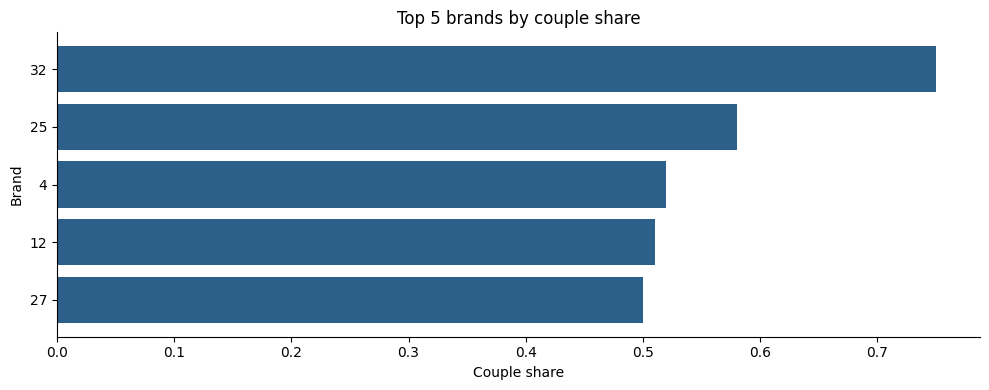


(b) gender share by brand
gender  Female  Male  Non-binary  not disclosed
brand                                          
0         0.42  0.55        0.00           0.03
1         0.46  0.52        0.00           0.01
2         0.47  0.50        0.00           0.02
3         0.37  0.61        0.00           0.02
4         0.50  0.48        0.00           0.02
5         0.59  0.38        0.00           0.03
6         0.49  0.48        0.00           0.03
7         0.48  0.48        0.00           0.03
8         0.46  0.51        0.00           0.03
9         0.51  0.45        0.00           0.03
10        0.44  0.52        0.00           0.03
11        0.50  0.46        0.00           0.04
12        0.49  0.50        0.00           0.01
13        0.47  0.50        0.00           0.03
14        0.47  0.50        0.00           0.03
15        0.55  0.42        0.00           0.03
16        0.42  0.56        0.00           0.02
17        0.49  0.49        0.00           0.02
18        0.5

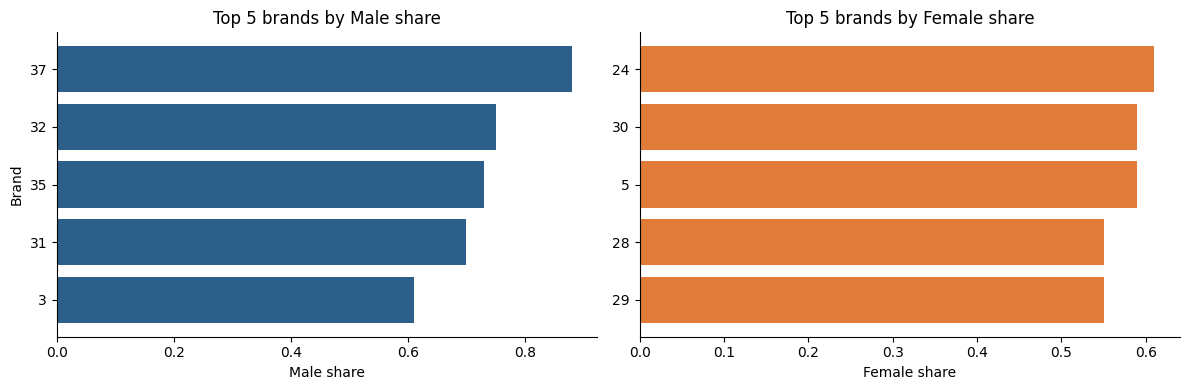


(c) trip type share by age group
trip_type      business  couple  family  friends  single
age_group                                               
18-24              0.14    0.40    0.15     0.18    0.13
25-34              0.19    0.36    0.24     0.11    0.10
35-54              0.26    0.25    0.34     0.07    0.08
55-64              0.20    0.44    0.18     0.09    0.09
65+                0.07    0.60    0.13     0.09    0.11
not disclosed      0.21    0.35    0.25     0.09    0.10


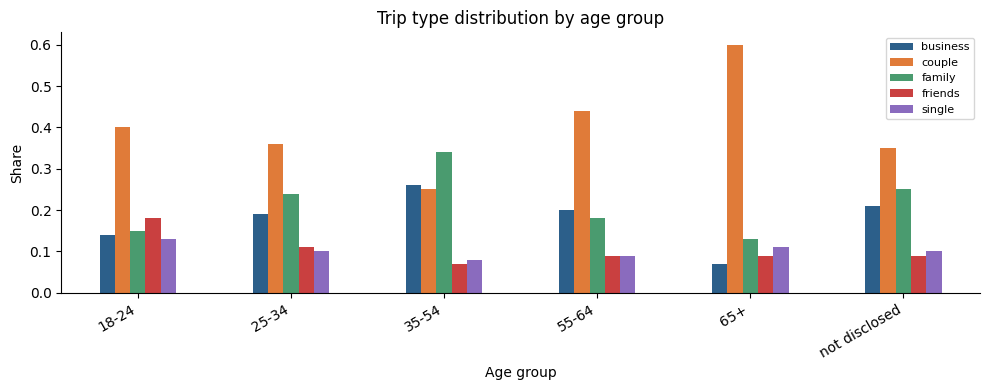

In [15]:
# --- 4.6  cross-tabulations ---
# (a) trip type vs brand    — which brands attract which traveller types
# (b) gender vs brand       — gender composition per brand
# (c) age group vs trip type — segment behaviour patterns

ct_trip_brand   = pd.crosstab(df['brand'],     df['trip_type'],  normalize='index').round(2)
ct_gender_brand = pd.crosstab(df['brand'],     df['gender'],     normalize='index').round(2)
ct_age_trip     = pd.crosstab(df['age_group'], df['trip_type'],  normalize='index').round(2)

# --- (a) trip type by brand ---
print('(a) trip type share by brand')
print(ct_trip_brand.to_string())

top5_couple = ct_trip_brand['couple'].sort_values(ascending=True).tail(5)
fig, ax = plt.subplots()
ax.barh(top5_couple.index.astype(str), top5_couple.values, color=PALETTE[0])
ax.set_title('Top 5 brands by couple share')
ax.set_xlabel('Couple share')
ax.set_ylabel('Brand')
plt.tight_layout()
plt.show()

# --- (b) gender by brand ---
print('\n(b) gender share by brand')
print(ct_gender_brand.to_string())

top5_male   = ct_gender_brand['Male'].sort_values(ascending=True).tail(5)
top5_female = ct_gender_brand['Female'].sort_values(ascending=True).tail(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.barh(top5_male.index.astype(str), top5_male.values, color=PALETTE[0])
ax1.set_title('Top 5 brands by Male share')
ax1.set_xlabel('Male share')
ax1.set_ylabel('Brand')

ax2.barh(top5_female.index.astype(str), top5_female.values, color=PALETTE[1])
ax2.set_title('Top 5 brands by Female share')
ax2.set_xlabel('Female share')

plt.tight_layout()
plt.show()


# --- (c) age group vs trip type ---
print('\n(c) trip type share by age group')
print(ct_age_trip.to_string())

ct_age_trip.plot(
    kind='bar',
    figsize=(10, 4),
    color=PALETTE[:ct_age_trip.shape[1]],
)
plt.title('Trip type distribution by age group')
plt.xlabel('Age group')
plt.ylabel('Share')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# Part 5: Sentiment Analysis
#
# Primary  : XLM-RoBERTa (cardiffnlp/twitter-xlm-roberta-base-sentiment)
#            handles EN and FR natively — no translation needed
# Secondary: VADER on EN-only reviews for methodological comparison
#
# Output columns added to df:
#   sentiment    — predicted label: positive / neutral / negative
#   sentiment_score — probability of the predicted label (model confidence)
#   vader_compound  — VADER compound score for EN reviews only (-1 to +1)
#
# Runtime note: T4 GPU is recommended.

import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print('device: GPU' if device == 0 else 'device: CPU — consider switching to GPU in Runtime settings')

device: GPU


In [17]:
# --- 5.1  XLM-RoBERTa inference ---

MODEL = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'

sentiment_pipe = pipeline(
    'text-classification',
    model=MODEL,
    tokenizer=MODEL,
    device=device,
    truncation=True,
    max_length=512,
)

from tqdm.auto import tqdm
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset

hf_dataset = Dataset.from_dict({'text': df['text'].tolist()})

results = list(tqdm(
    sentiment_pipe(KeyDataset(hf_dataset, 'text'), batch_size=64),
    total=len(df),
    desc='XLM-RoBERTa inference',
))

df['sentiment']       = [r['label'].lower() for r in results]
df['sentiment_score'] = [round(r['score'], 4) for r in results]

print('inference complete')
print(df['sentiment'].value_counts().to_string())

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

XLM-RoBERTa inference:   0%|          | 0/47741 [00:00<?, ?it/s]

inference complete
sentiment
positive    32895
negative    13941
neutral       905


In [18]:
# --- 5.2  VADER on EN reviews (secondary / comparison) ---

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

# apply only to EN reviews; FR rows get None
df['vader_compound'] = df.apply(
    lambda row: vader.polarity_scores(row['text'])['compound']
    if row['language'] == 'en' else None,
    axis=1,
)

print('VADER complete')
print('EN reviews scored :', df['vader_compound'].notna().sum())
print('FR reviews (None) :', df['vader_compound'].isna().sum())

VADER complete
EN reviews scored : 28787
FR reviews (None) : 18954


In [19]:
# --- 5.3  model comparison on EN reviews ---
# VADER compound thresholds: >= 0.05 positive, <= -0.05 negative, else neutral

en = df[df['language'] == 'en'].copy()

en['vader_label'] = en['vader_compound'].apply(
    lambda s: 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
)

agreement = (en['sentiment'] == en['vader_label']).mean()
print('XLM-RoBERTa vs VADER agreement on EN reviews:', round(agreement, 3))

print('\nXLM-RoBERTa label distribution (EN only)')
print(en['sentiment'].value_counts().to_string())

print('\nVADER label distribution (EN only)')
print(en['vader_label'].value_counts().to_string())

XLM-RoBERTa vs VADER agreement on EN reviews: 0.788

XLM-RoBERTa label distribution (EN only)
sentiment
positive    19236
negative     8818
neutral       733

VADER label distribution (EN only)
vader_label
positive    24290
negative     3729
neutral       768


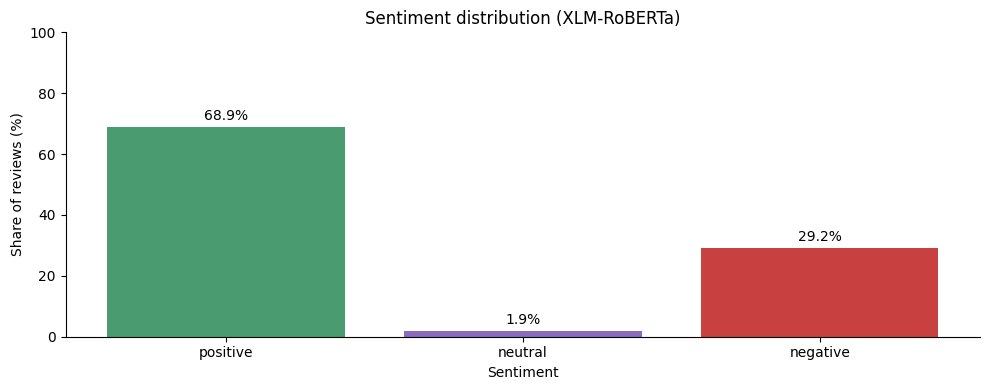

In [20]:
# --- 5.4  sentiment distribution overview ---

order  = ['positive', 'neutral', 'negative']
colors = [PALETTE[2], PALETTE[4], PALETTE[3]]
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
bars = ax.bar(
    [s for s in order if s in sentiment_pct],
    [sentiment_pct.get(s, 0) for s in order],
    color=[c for s, c in zip(order, colors) if s in sentiment_pct],
)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Sentiment distribution (XLM-RoBERTa)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Share of reviews (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

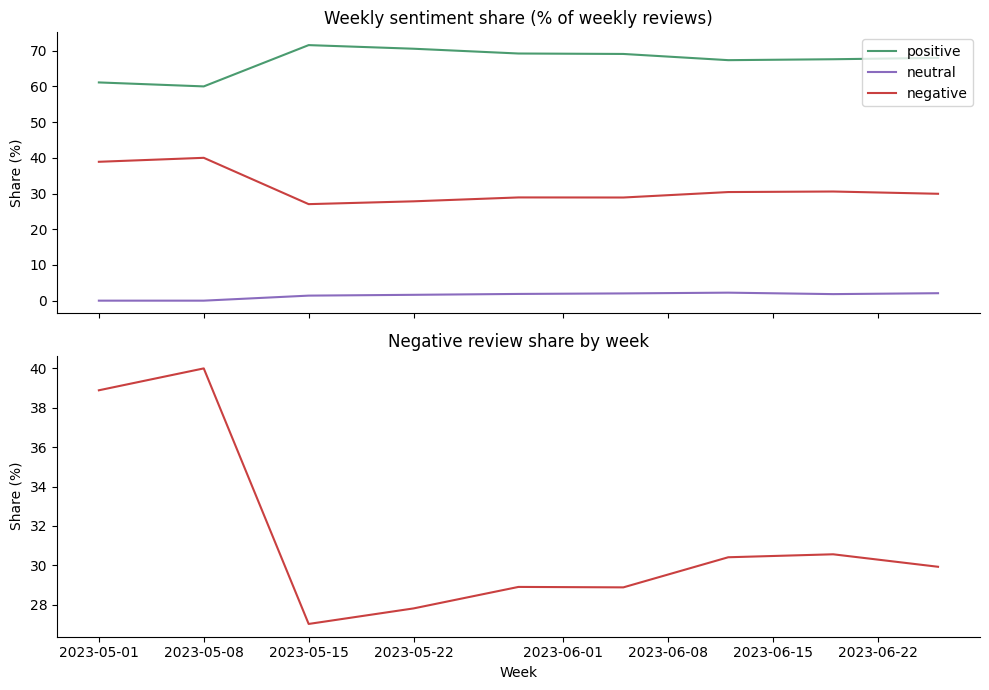

In [97]:
# --- 5.5  weekly sentiment trend ---
# top panel : weekly share of each sentiment class — shows the overall
#             composition and provides context for the negative share panel
# bottom panel: negative review share week-by-week — zooms in on the key signal

weekly_sentiment_share = (
    df.groupby(['week', 'sentiment']).size()
    .unstack('sentiment')
    .fillna(0)
    .apply(lambda row: row / row.sum() * 100, axis=1)
)

weekly_neg_share = (
    df.groupby('week')
    .apply(lambda g: (g['sentiment'] == 'negative').mean() * 100)
    .rename('negative_share')
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for label, color in zip(['positive', 'neutral', 'negative'], [PALETTE[2], PALETTE[4], PALETTE[3]]):
    if label in weekly_sentiment_share.columns:
        ax1.plot(weekly_sentiment_share.index, weekly_sentiment_share[label],
                 label=label, color=color, linewidth=1.5)
ax1.set_title('Weekly sentiment share (% of weekly reviews)')
ax1.set_ylabel('Share (%)')
ax1.legend()

ax2.plot(weekly_neg_share.index, weekly_neg_share.values, color=PALETTE[3], linewidth=1.5)
ax2.set_title('Negative review share by week')
ax2.set_ylabel('Share (%)')
ax2.set_xlabel('Week')

plt.tight_layout()
plt.show()

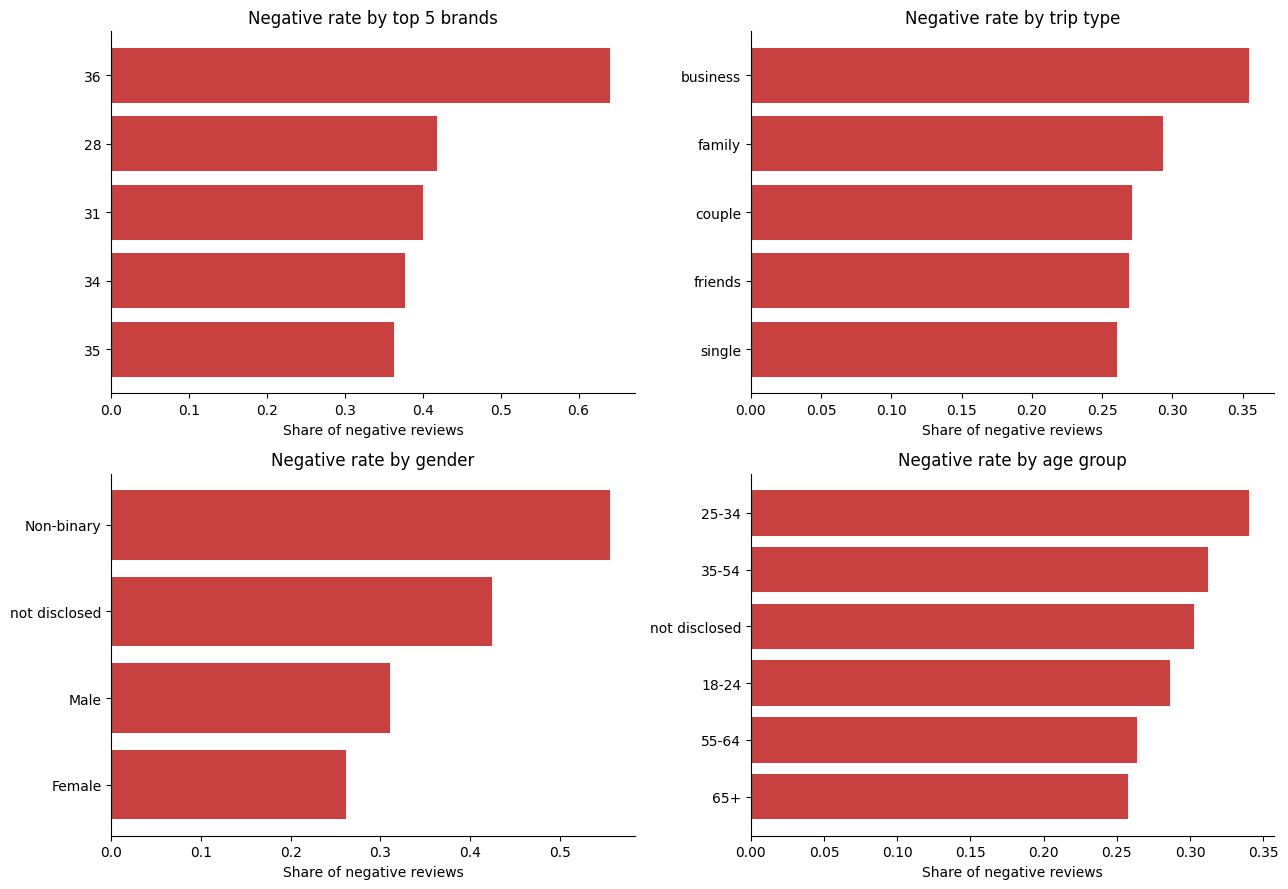


top 5 brands by negative rate
brand
36    0.640
28    0.418
31    0.400
34    0.377
35    0.364


In [22]:
# --- 5.6  EDA revisited — negative rate by segment ---
# integrates sentiment with the demographic and brand dimensions from Part 4

def neg_rate(series):
    return (series == 'negative').mean()

# top 5 brands only — all 38 brands make the chart unreadable
top5_neg_brands = df.groupby('brand')['sentiment'].apply(neg_rate)\
                    .sort_values(ascending=False).head(5)\
                    .sort_values(ascending=True)
neg_by_brand  = top5_neg_brands
neg_by_trip   = df.groupby('trip_type')['sentiment'].apply(neg_rate).sort_values(ascending=True)
neg_by_gender = df.groupby('gender')['sentiment'].apply(neg_rate).sort_values(ascending=True)
neg_by_age    = df.groupby('age_group')['sentiment'].apply(neg_rate).sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, data, title in zip(
    axes.flat,
    [neg_by_brand, neg_by_trip, neg_by_gender, neg_by_age],
    ['Negative rate by top 5 brands', 'Negative rate by trip type',
     'Negative rate by gender', 'Negative rate by age group'],
):
    ax.barh(data.index.astype(str), data.values, color=PALETTE[3])
    ax.set_title(title)
    ax.set_xlabel('Share of negative reviews')

plt.tight_layout()
plt.show()

print()
print('top 5 brands by negative rate')
print(neg_by_brand.sort_values(ascending=False).head().round(3).to_string())

In [25]:
# Part 6: Negative Review Theme Extraction (BERTopic)
#
# Objective: identify the top 3 operational areas driving dissatisfaction
# across all brands and segments.
#
# Approach:
#   - filter to negative reviews only
#   - embed with a multilingual sentence encoder (handles EN and FR natively)
#   - cluster with BERTopic to surface recurring complaint themes
#   - select top 3 most frequent topics for the business recommendation

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# --- 6.1  isolate negative reviews ---
neg = df[df['sentiment'] == 'negative'].reset_index(drop=True)

print('negative reviews :', len(neg))
print('language split   :')
print(neg['language'].value_counts().to_string())

negative reviews : 13941
language split   :
language
en    8818
fr    5123


In [26]:
# --- 6.2  embed negative reviews ---
# paraphrase-multilingual-MiniLM-L12-v2 is compact and handles EN/FR
# without translation; faster than XLM-R at embedding scale

EMBED_MODEL = 'paraphrase-multilingual-MiniLM-L12-v2'
embedder = SentenceTransformer(EMBED_MODEL)

print('embedding', len(neg), 'negative reviews...')
embeddings = embedder.encode(
    neg['text'].tolist(),
    batch_size=128,
    show_progress_bar=True,
)
print('embedding shape:', embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedding 13941 negative reviews...


Batches:   0%|          | 0/109 [00:00<?, ?it/s]

embedding shape: (13941, 384)


In [36]:
# --- 6.3  fit BERTopic ---
# fix from previous run: HDBSCAN was finding only 2 clusters because
# min_cluster_size was too large relative to natural cluster density.
# passing explicit HDBSCAN with min_cluster_size=15 and removing
# nr_topics='auto' which was merging the few clusters found.

from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from hdbscan import HDBSCAN
import nltk

nltk.download('stopwords', quiet=True)

stop_en = stopwords.words('english')
stop_fr = stopwords.words('french')
stop_combined = list(set(stop_en + stop_fr))

vectorizer = CountVectorizer(stop_words=stop_combined, ngram_range=(1, 2))

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=embedder,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    min_topic_size=15,
    language='multilingual',
    verbose=True,
)

topics, probs = topic_model.fit_transform(neg['text'].tolist(), embeddings)
neg['topic'] = topics

topic_info = topic_model.get_topic_info()
print(topic_info[topic_info['Topic'] != -1].to_string())

2026-05-03 11:33:48,386 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 11:33:58,565 - BERTopic - Dimensionality - Completed ✓
2026-05-03 11:33:58,566 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 11:33:59,581 - BERTopic - Cluster - Completed ✓
2026-05-03 11:33:59,589 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 11:34:02,364 - BERTopic - Representation - Completed ✓


   Topic  Count                                    Name                                                                       Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [40]:
# --- diagnostic: sentiment score distribution within topic 0 ---

print('sentiment_score distribution in topic 0 negative reviews')
print(neg[neg['topic'] == 0]['sentiment_score'].describe().round(3).to_string())

print('\nshare of low-confidence negatives (score < 0.6) in topic 0')
low_conf = (neg[neg['topic'] == 0]['sentiment_score'] < 0.6).mean()
print(round(low_conf, 3))

print('\nthree lowest-confidence examples in topic 0')
lowest = (
    neg[neg['topic'] == 0]
    .sort_values('sentiment_score')
    .head(3)[['text', 'sentiment_score']]
)
for _, row in lowest.iterrows():
    print(f"  score {row['sentiment_score']:.3f} — {row['text'][:120]}")

sentiment_score distribution in topic 0 negative reviews
count    13464.000
mean         0.746
std          0.184
min          0.337
25%          0.586
50%          0.806
75%          0.912
max          0.974

share of low-confidence negatives (score < 0.6) in topic 0
0.266

three lowest-confidence examples in topic 0
  score 0.337 — I usually choose small hotels but on this occasion I could not find one.  So was surprised to find I enjoyed our stay wi
  score 0.338 — The hotel staff, from the reception to the maids to the doorman always had a smile on their faces and were super friendl
  score 0.340 — The location is superb, near to Central station and most of the famous site. We were given a low floor room but the soun


In [65]:
# --- 6.3a rerun BERTopic on high-confidence negative reviews ---
# filter at mean sentiment score to remove ambiguous negatives before clustering

threshold = neg['sentiment_score'].mean()
mask      = neg['sentiment_score'] >= threshold

neg_filtered        = neg[mask].reset_index(drop=True)
embeddings_filtered = embeddings[mask.values]

print(f'threshold         : {threshold:.3f}')
print(f'reviews kept      : {len(neg_filtered)} / {len(neg)} ({mask.mean():.1%})')

topics, probs = topic_model.fit_transform(
    neg_filtered['text'].tolist(),
    embeddings_filtered,
)
neg_filtered['topic'] = topics

topic_info = topic_model.get_topic_info()
print(topic_info[topic_info['Topic'] != -1].to_string())

2026-05-03 13:01:20,641 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


threshold         : 0.745
reviews kept      : 8041 / 13941 (57.7%)


2026-05-03 13:01:34,105 - BERTopic - Dimensionality - Completed ✓
2026-05-03 13:01:34,106 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 13:01:34,737 - BERTopic - Cluster - Completed ✓
2026-05-03 13:01:34,744 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 13:01:36,476 - BERTopic - Representation - Completed ✓


   Topic  Count                                    Name                                                                       Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [76]:
# --- 6.3b  human-readable topic labels ---

TOPIC_LABELS = {
    0 : 'room_and_service',
    1 : 'ibis_value_ratio',
    2 : 'food_and_breakfast',
    -1: 'outlier',
}

neg_filtered['topic_label'] = neg_filtered['topic'].map(TOPIC_LABELS).fillna('outlier')

print('topic label distribution')
print(neg_filtered['topic_label'].value_counts().to_string())

topic label distribution
topic_label
room_and_service      7797
ibis_value_ratio       223
food_and_breakfast      21


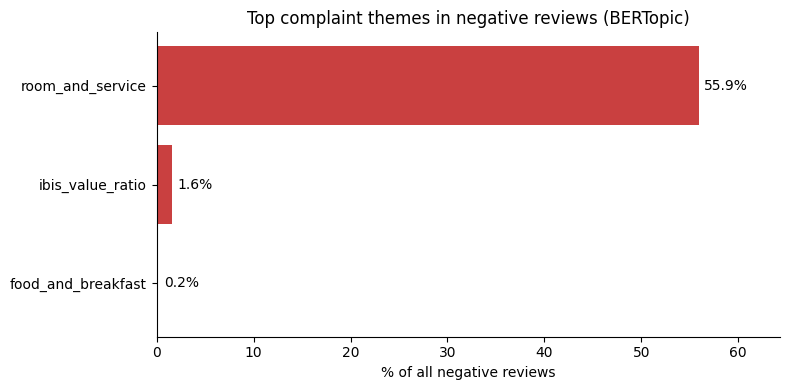

In [94]:
# --- 6.4  top topics bar chart (% of all negative reviews) ---
# denominator is the full negative set (13,941) not the filtered subset

n_all_neg = (df['sentiment'] == 'negative').sum()

topic_pct = (
    neg_filtered[neg_filtered['topic'] != -1]
    .groupby('topic_label').size()
    / n_all_neg * 100
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(topic_pct.index, topic_pct.values, color=PALETTE[3])
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_title('Top complaint themes in negative reviews (BERTopic)')
ax.set_xlabel('% of all negative reviews')
ax.set_xlim(0, topic_pct.max() * 1.15)
plt.tight_layout()
plt.show()

In [78]:
# --- 6.5  top 3 topics — representative reviews ---

top3_ids = (
    topic_info[topic_info['Topic'] != -1]
    .sort_values('Count', ascending=False)
    .head(3)['Topic']
    .tolist()
)

for topic_id in top3_ids:
    name     = TOPIC_LABELS.get(topic_id, str(topic_id))
    count    = topic_model.get_topic_info(topic_id)['Count'].values[0]
    words    = [w for w, _ in topic_model.get_topic(topic_id)[:6]]
    examples = neg_filtered[neg_filtered['topic'] == topic_id]['text'].head(3).tolist()

    print(f'topic {topic_id} — {name}  ({count} reviews)')
    print('  keywords:', ', '.join(words))
    print('  examples:')
    for ex in examples:
        print(f'    - {ex[:120]}')
    print()

topic 0 — room_and_service  (7797 reviews)
  keywords: room, hotel, chambre, très, staff, good
  examples:
    - There was no service at the bar on the ground floor. The staff is untrained and does not seem to be motivated enough
    - We stayed for the weekend. Arrived Saturday left Sunday. Room 509 with small balcony but perfectly centered with sunset.
    - Very disappointing. Stayed in King with terrace in Garden Wing with my dog. I think it was supposed to be “deluxe”.  Pre

topic 1 — ibis_value_ratio  (223 reviews)
  keywords: ibis, chambre, hotel, très, room, hôtel
  examples:
    - Très décevant pour un ibis style. Hôtel vieillissant.
Propreté de la chambre laissant à désirer. Du moisis atout des fen
    - L’hôtel n’est pas responsable mais compliqué d’y arriver avec l’A1 fermée. Pour l’hôtel en lui même, l’hôtel semble réce
    - Globalement très bien sauf 2 points:
- chambre donnant sur la rue très bruyante. Peut-etre les doubles vitrages sont -il

topic 2 — food_and_breakfas

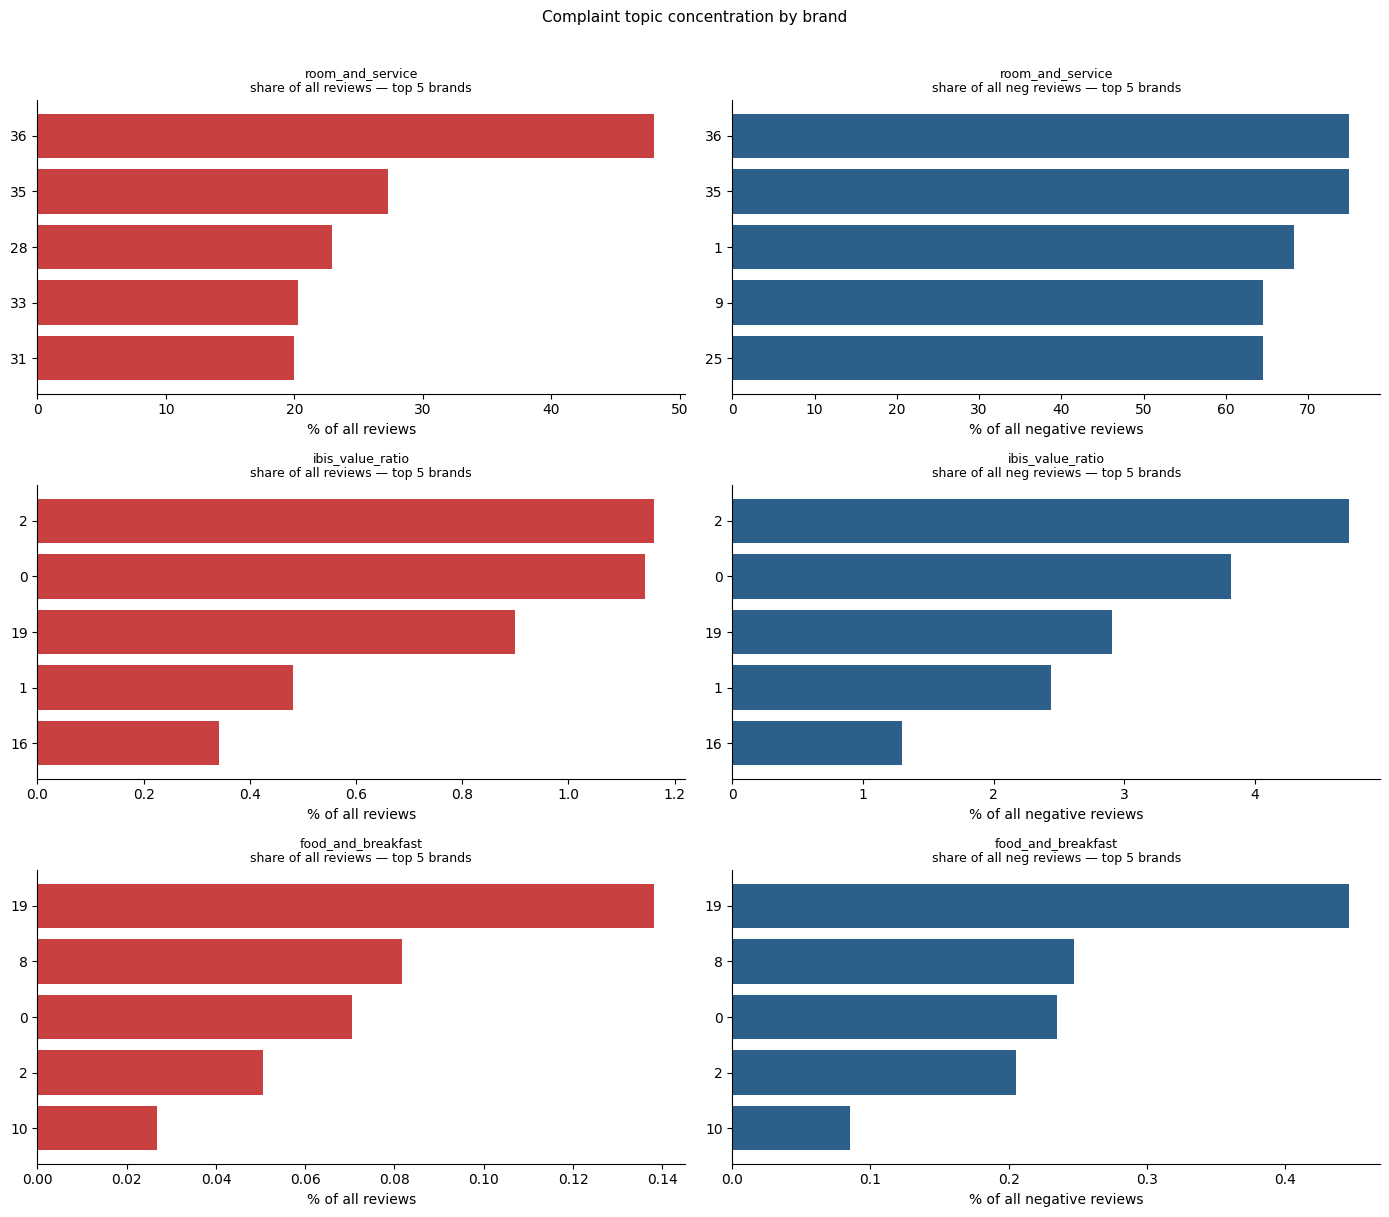

In [91]:
# --- 6.6  complaint topics — brand concentration (6 subplots) ---
# left column  : % of all reviews       — magnitude across total guest volume
# right column : % of all negative reviews   — concentration within all dissatisfied guests

n_all_neg = (df['sentiment'] == 'negative').sum()
neg_all   = df[df['sentiment'] == 'negative']  # unfiltered negative reviews

valid_topics = [t for t in TOPIC_LABELS if t != -1]
topic_names  = [TOPIC_LABELS[t] for t in valid_topics]

fig, axes = plt.subplots(len(valid_topics), 2, figsize=(14, 4 * len(valid_topics)))

for row, (topic_id, topic_name) in enumerate(zip(valid_topics, topic_names)):
    topic_reviews = neg_filtered[neg_filtered['topic'] == topic_id]

    # left: share of all reviews per brand
    share_all = (
        topic_reviews.groupby('brand').size()
        / df.groupby('brand').size()
    ).dropna().sort_values(ascending=True).tail(5) * 100

    # right: share of all negative reviews per brand
    share_neg = (
        topic_reviews.groupby('brand').size()
        / neg_all.groupby('brand').size()
    ).dropna().sort_values(ascending=True).tail(5) * 100

    axes[row, 0].barh(share_all.index.astype(str), share_all.values, color=PALETTE[3])
    axes[row, 0].set_title(f'{topic_name}\nshare of all reviews — top 5 brands', fontsize=9)
    axes[row, 0].set_xlabel('% of all reviews')

    axes[row, 1].barh(share_neg.index.astype(str), share_neg.values, color=PALETTE[0])
    axes[row, 1].set_title(f'{topic_name}\nshare of all neg reviews — top 5 brands', fontsize=9)
    axes[row, 1].set_xlabel('% of all negative reviews')

plt.suptitle('Complaint topic concentration by brand', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

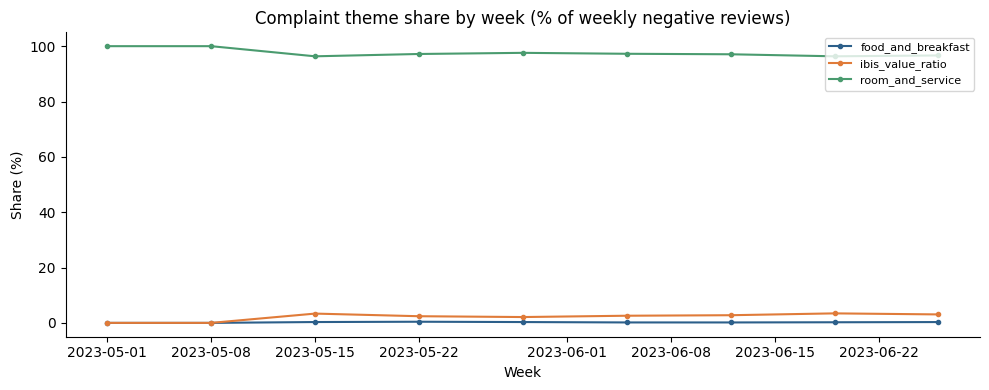

In [92]:
# --- 6.7  complaint theme trend over the two-month window ---
# neg_filtered may already carry 'week' from df; avoid merge suffix conflicts
# by adding week only if the column is not already present

if 'week' not in neg_filtered.columns:
    week_map = df.drop_duplicates(subset=['text', 'date']).set_index(['text', 'date'])['week']
    neg_filtered['week'] = [
        week_map.get((row.text, row.date), None)
        for row in neg_filtered[['text', 'date']].itertuples(index=False)
    ]

weekly_topic = (
    neg_filtered[neg_filtered['topic'] != -1]
    .groupby(['week', 'topic_label']).size()
    .unstack('topic_label')
    .fillna(0)
)
weekly_topic_pct = weekly_topic.div(weekly_topic.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
for col, color in zip(weekly_topic_pct.columns, PALETTE):
    ax.plot(
        weekly_topic_pct.index, weekly_topic_pct[col],
        label=col, color=color, linewidth=1.5, marker='o', markersize=3,
    )
ax.set_title('Complaint theme share by week (% of weekly negative reviews)')
ax.set_xlabel('Week')
ax.set_ylabel('Share (%)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [101]:
# brand 36 exact figures
brand36_total = (df['brand'] == 36).sum()
brand36_neg   = ((df['brand'] == 36) & (df['sentiment'] == 'negative')).sum()
brand36_topic0 = ((neg_filtered['brand'] == 36) & (neg_filtered['topic'] == 0)).sum()

print('brand 36 — total reviews      :', brand36_total)
print('brand 36 — negative rate      :', round(brand36_neg / brand36_total, 3))
print('brand 36 — topic0 / total     :', round(brand36_topic0 / brand36_total, 3))
print('brand 36 — topic0 / neg total :', round(brand36_topic0 / brand36_neg, 3))

brand 36 — total reviews      : 25
brand 36 — negative rate      : 0.64
brand 36 — topic0 / total     : 0.48
brand 36 — topic0 / neg total : 0.75


In [102]:
# Part 7: Business recommendations

conclusions = """
Priority 1 — Room quality and service consistency
  55.9% of all negative reviews fall into this topic (Part 6, cell 6.4).
  Brand 36 is the key outlier: 64% negative rate, only 25 total reviews,
  and 75% of its negative reviews concern room and service (Part 5, cell 5.6;
  Part 6, cell 6.6). Its small volume means one bad experience has outsized
  impact on the brand negative rate. Brands 35, 28, 33, and 31 are also
  heavily affected at scale. Business travellers have the highest negative
  rate at 35.5% and the 25-34 age group is the most dissatisfied segment
  at 34% (Part 5, cell 5.6). The theme held stable at ~98% of weekly
  negative reviews across the two months with no improvement (Part 6, cell 6.7).

Priority 2 — Ibis room quality vs price
  1.6% of all negative reviews fall into this topic (Part 6, cell 6.4).
  Concentrated in brands 2 and 0. Guests compare the Ibis experience
  unfavourably against Ibis Budget for similar price points.
  Actionable through targeted room refurbishment rather than group-wide
  service training.

Priority 3 — Breakfast quality
  0.2% of all negative reviews (Part 6, cell 6.4), concentrated in brand 19.
  French-language reviews dominate this cluster. Low priority for group-wide
  action; brand 19 should review its breakfast offering.

Trend:
  Negative share dropped from ~40% in early May to ~28% by mid-May and
  stayed stable through June (Part 5, cell 5.5). Topic composition did not
  change — the May spike reflects a volume event, not a new failure category.

Recommended actions:
  1. Investigate brand 36 — 64% negative rate on 25 reviews warrants a
     direct property audit rather than a group-wide programme.
  2. Set minimum service standards for business traveller segments.
  3. Review room quality and pricing communication for Ibis brands 2 and 0.
"""

print(conclusions)


Priority 1 — Room quality and service consistency
  55.9% of all negative reviews fall into this topic (Part 6, cell 6.4).
  Brand 36 is the key outlier: 64% negative rate, only 25 total reviews,
  and 75% of its negative reviews concern room and service (Part 5, cell 5.6;
  Part 6, cell 6.6). Its small volume means one bad experience has outsized
  impact on the brand negative rate. Brands 35, 28, 33, and 31 are also
  heavily affected at scale. Business travellers have the highest negative
  rate at 35.5% and the 25-34 age group is the most dissatisfied segment
  at 34% (Part 5, cell 5.6). The theme held stable at ~98% of weekly
  negative reviews across the two months with no improvement (Part 6, cell 6.7).

Priority 2 — Ibis room quality vs price
  1.6% of all negative reviews fall into this topic (Part 6, cell 6.4).
  Concentrated in brands 2 and 0. Guests compare the Ibis experience
  unfavourably against Ibis Budget for similar price points.
  Actionable through targeted room r